Dataset used: https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data

In [40]:
!pip install dagshub -q

A. Task Performed

1.   Importing Libraries
2.   Loading the Dataset from Dagshub Repo Storage
3.   Checked the Shape of the Dataset
4.   an Overview of Dataset using head() method






In [41]:
import dagshub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Authenticate Colab session (one-time popup to grant access)
dagshub.auth.add_app_token(token="847f9c982db9197effd90d58ae279bd6f3d4c704")  # or run dagshub.login()

# Define your repo coordinates
REPO_OWNER = "PriyoChand"
REPO_NAME = "used-car-global-valuation"

# Stream CSV directly on demand via DAGsHub raw/streaming URL
# Replace with 'cardekho_dataset.csv' or 'vehicles.csv'
url = f"https://dagshub.com/{REPO_OWNER}/{REPO_NAME}/raw/main/data/raw/cardekho_dataset.csv"

# Pandas reads the stream directly over HTTP
df = pd.read_csv(url)
print(f"Loaded shape: {df.shape}")
df.head()

Loaded shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


B. Task Performed

1.   Overview of the dataset from bottom


In [42]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


 C. Tasks Performed


1.  Summary of the Dataset




In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


 D. Tasks Performed


1.    Statistical Summary of the Dataset

      Anomalies:
      vehicle_age=0 (Divison by Zero error)

In [44]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,9811.86,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,5643.42,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4906.50,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,9872.00,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,14668.50,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,19543.00,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [45]:
df[df['vehicle_age']==0]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
5078,6451,Maruti Ignis,Maruti,Ignis,0,5000,Individual,Petrol,Manual,20.89,1197,81.80,5,550000
7789,9985,Mahindra KUV,Mahindra,KUV,0,30000,Individual,Petrol,Manual,18.15,1198,82.00,6,400000
10315,13164,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
11486,14576,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
12157,15420,Maruti S-Presso,Maruti,S-Presso,0,5000,Individual,Petrol,Manual,21.70,998,67.00,5,500000


E. Task Performed

1.   Droping the Useless Index Column and redundent car_name column present in the Dataset
2.   Casting Selling_price column to float64 from int64


In [46]:
# 1. Drop redundant columns
cols_to_drop = [col for col in ["Unnamed: 0", "car_name"] if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 2. Cast target variable column to continuous numeric variable
df["selling_price"]=df["selling_price"].astype("float64")

# 3. Verify the updated schema and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15411 non-null  object 
 1   model              15411 non-null  object 
 2   vehicle_age        15411 non-null  int64  
 3   km_driven          15411 non-null  int64  
 4   seller_type        15411 non-null  object 
 5   fuel_type          15411 non-null  object 
 6   transmission_type  15411 non-null  object 
 7   mileage            15411 non-null  float64
 8   engine             15411 non-null  int64  
 9   max_power          15411 non-null  float64
 10  seats              15411 non-null  int64  
 11  selling_price      15411 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


F. Task Performed


1.    Check how many duplicates exist
2.   Drop identical rows while keeping the first occurrence



In [47]:
# Check how many duplicates exist
print("Duplicate rows count:", df.duplicated().sum())

# Drop identical rows while keeping the first occurrence
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows count: 167
Dataset shape after removing duplicates: (15244, 12)


G. Tasks Performed


1.    Statistical Summary of the Dataset after Droping Duplicates rows, unnecessary columns


In [48]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00
mean,6.04,55639.58,19.70,1486.17,100.61,5.33,774701.45
std,3.02,51766.30,4.17,520.42,42.92,0.81,894676.08
min,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,559000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


H. Task Performed

1.   Checking for Null Values



In [49]:
df.isnull().sum()

,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0
max_power,0


I. task Performed

1.   Cleans away obvious corrupt entries and very extreme values
2.   Identifying Invalid values in Seats Column
3.   Replacing Invalid Values in Seats Column with Actual Value



In [50]:
df = df[df["km_driven"] < 500000].reset_index(drop=True)

In [51]:
zero_seats_count = (df["seats"] == 0).sum()
print(
    f"Rows with 0 seats: {zero_seats_count} ({zero_seats_count / len(df):.2%})"
)
df[df['seats']==0]

Rows with 0 seats: 2 (0.01%)


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3205,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000.00
12491,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000.00


In [52]:
exact_seats = {"Honda City": 5, "Nissan Kicks": 5}

# 1. Update the 0 values using map
mapped_values = df["model"].map(exact_seats)
df["seats"] = np.where(df["seats"] == 0, mapped_values, df["seats"])

# 2. Check if any NaNs exist and fill them with median
df["seats"] = df["seats"].fillna(df["seats"].median())

# 3. Now safely convert to int
df["seats"] = df["seats"].astype(int)

J. Task Performed
1. Data Formatting and Standarization for all categorical (object) columns




In [53]:
# Identify all categorical (object) columns
string_cols = ["brand", "model", "seller_type", "fuel_type", "transmission_type"]

# 1. Print all unique values for each string column
print("--- AUDITING UNIQUE VALUES ---")
for col in string_cols:
    print(f"\nColumn: '{col}' | Total Unique Values: {df[col].nunique()}")
    print(df[col].unique())

# 2. Check for hidden spaces (leading/trailing whitespace)
print("\n--- CHECKING FOR HIDDEN SPACES ---")
for col in string_cols:
    has_spaces = df[col].astype(str).str.contains(r"^\s|\s$", regex=True).any()
    print(f"Column '{col}' has leading/trailing spaces: {has_spaces}")

# 3. Check for casing inconsistencies (e.g., 'petrol' vs 'Petrol')
print("\n--- CHECKING FOR CASE DIFFERENCES ---")
for col in string_cols:
    original_unique = df[col].nunique()
    title_case_unique = df[col].astype(str).str.title().nunique()
    if original_unique != title_case_unique:
        print(f"Column '{col}' has case inconsistencies! ({original_unique} original vs {title_case_unique} standard)")
    else:
        print(f"Column '{col}' case is consistent.")

--- AUDITING UNIQUE VALUES ---

Column: 'brand' | Total Unique Values: 32
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']

Column: 'model' | Total Unique Values: 120
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' 'Z4' '6' 'XF' 'X5' 'Hector' 'Civic' 'D-Max'
 'Cayenne' 'X1' 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300' 'Dzire VXI'
 'S90' 'WR

In [54]:
# ----------------------------------------------------
# 1. Fix Case Inconsistency in 'brand' ('ISUZU' -> 'Isuzu')
# ----------------------------------------------------
df["brand"] = df["brand"].astype(str).str.strip().str.title()

# ----------------------------------------------------
# 2. Standardize Model Variant Names & Trim Noise
# ----------------------------------------------------
model_corrections = {
    "Redi-Go": "Redigo",
    "Redigo": "Redigo",
    "Dzire Vxi": "Dzire",
    "Dzire Lxi": "Dzire",
    "Dzire Zxi": "Dzire",
    "Swift Dzire": "Dzire",
}

df["model"] = df["model"].astype(str).str.strip().str.title()
df["model"] = df["model"].replace(model_corrections)

# ----------------------------------------------------
# 3. Re-Verify Brand Count
# ----------------------------------------------------
print("Updated Unique Brands Count:", df["brand"].nunique())
print("Updated Unique Models Count:", df["model"].nunique())

Updated Unique Brands Count: 31
Updated Unique Models Count: 116


In [55]:
print("Duplicate rows count:", df.duplicated().sum())


Duplicate rows count: 0


-----------------------------------------Exploratory Data Analysis-----------------------------------------

[] Univariate Analysis (Individual Distributions)




In [56]:
# Visual formatting setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [57]:
# Define feature groups
target = 'selling_price'
num_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
cat_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type']

Statistical Summary & Distribution Metrics of Selling_price feature

In [58]:
# 1. Statistical Summary & Distribution Metrics
price = df["selling_price"]
print("--- TARGET VARIABLE METRICS: selling_price ---")
print(f"Mean Price      : ₹{price.mean():,.2f}")
print(f"Median Price    : ₹{price.median():,.2f}")
print(f"Standard Dev    : ₹{price.std():,.2f}")
print(f"Skewness        : {price.skew():.2f} (Rule: > 1.0 indicates severe right-skew)")
print(f"Kurtosis        : {price.kurtosis():.2f}")

--- TARGET VARIABLE METRICS: selling_price ---
Mean Price      : ₹774,622.38
Median Price    : ₹557,500.00
Standard Dev    : ₹894,874.45
Skewness        : 10.11 (Rule: > 1.0 indicates severe right-skew)
Kurtosis        : 284.29


Target Variable Analysis (selling_price)

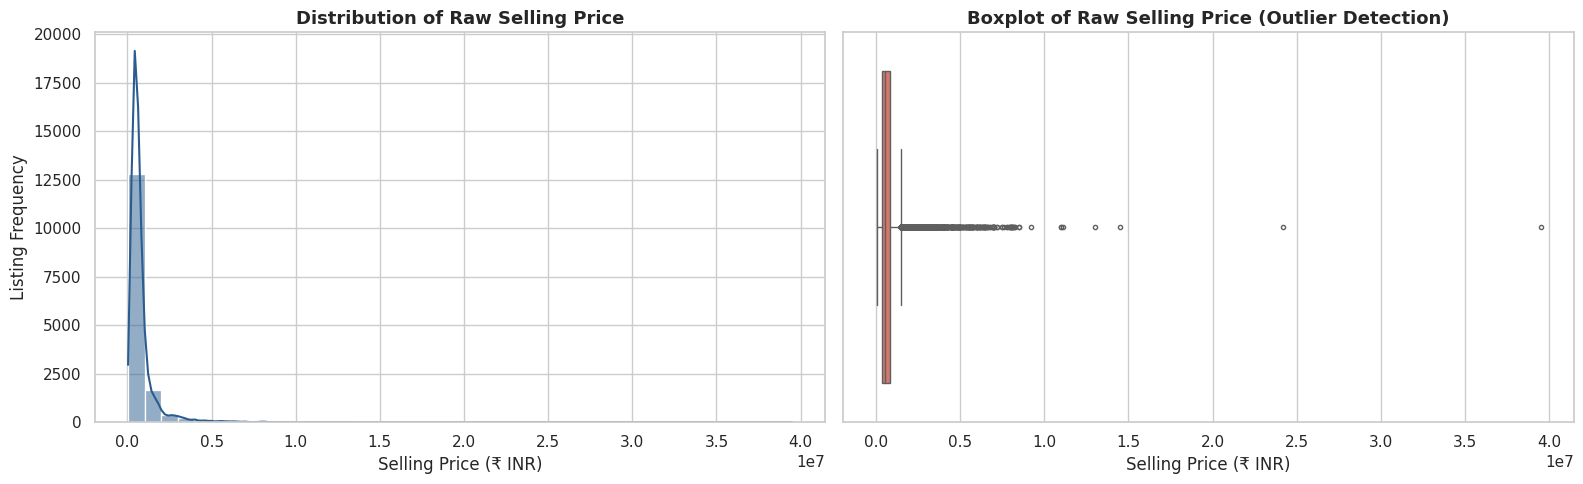

In [59]:
# 2. Side-by-Side Visualization: Histogram + KDE & Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution Plot
sns.histplot(price, kde=True, ax=axes[0], color="#2b5c8f", bins=40)
axes[0].set_title("Distribution of Raw Selling Price", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Selling Price (₹ INR)")
axes[0].set_ylabel("Listing Frequency")

# Boxplot
sns.boxplot(x=price, ax=axes[1], color="#e26d5c", flierprops={"marker": "o", "markersize": 3})
axes[1].set_title("Boxplot of Raw Selling Price (Outlier Detection)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Selling Price (₹ INR)")

plt.tight_layout()
plt.show()

Log-Transformation Validation


--- POST LOG-TRANSFORMATION METRICS ---
Log Skewness    : 0.56 (Rule: Between -0.5 and 0.5 is near-normal)


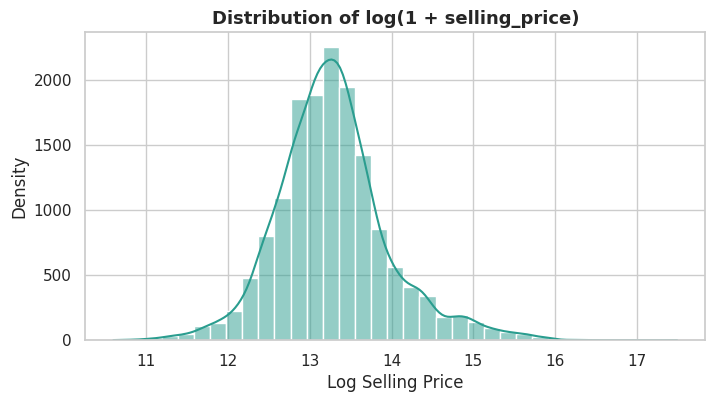

In [60]:
# 3. Log-Transformation Validation (IBM DA0101EN Normalization Technique)
log_price = np.log1p(price)
print("\n--- POST LOG-TRANSFORMATION METRICS ---")
print(f"Log Skewness    : {log_price.skew():.2f} (Rule: Between -0.5 and 0.5 is near-normal)")

plt.figure(figsize=(8, 4))
sns.histplot(log_price, kde=True, color="#2a9d8f", bins=35)
plt.title("Distribution of log(1 + selling_price)", fontsize=13, fontweight="bold")
plt.xlabel("Log Selling Price")
plt.ylabel("Density")
plt.show()

In [61]:
# 1. Statistical Summary & Distribution Metrics
print("--- TARGET VARIABLE METRICS: log_selling_price ---")
print(f"Mean Price      : ₹{log_price.mean():,.2f}")
print(f"Median Price    : ₹{log_price.median():,.2f}")
print(f"Standard Dev    : ₹{log_price.std():,.2f}")
print(f"Skewness        : {log_price.skew():.2f} (Rule: > 1.0 indicates severe right-skew)")
print(f"Kurtosis        : {log_price.kurtosis():.2f}")

--- TARGET VARIABLE METRICS: log_selling_price ---
Mean Price      : ₹13.28
Median Price    : ₹13.23
Standard Dev    : ₹0.69
Skewness        : 0.56 (Rule: > 1.0 indicates severe right-skew)
Kurtosis        : 1.47


The target variable selling_price showed significant right-skewness and high kurtosis due to high-end luxury vehicle listings. Rather than discarding valid luxury observations, I applied a $\log(1 + y)$ transformation, which shifted the skewness into a $[-0.5, 0.5]$ range, stabilizing residual variance for regression.

Numerical Predictor Distributions

In [62]:
numeric_cols = ["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats"]

# Summary statistics table
display(df[numeric_cols].describe().T[["mean", "std", "min", "50%", "max"]])

,mean,std,min,50%,max
vehicle_age,6.04,3.02,0.00,6.00,29.00
km_driven,54805.63,36246.81,100.00,50000.00,480000.00
mileage,19.70,4.17,4.00,19.67,33.54
engine,1485.79,520.17,793.00,1248.00,6592.00
max_power,100.60,42.92,38.40,88.50,626.00
seats,5.33,0.81,2.00,5.00,9.00


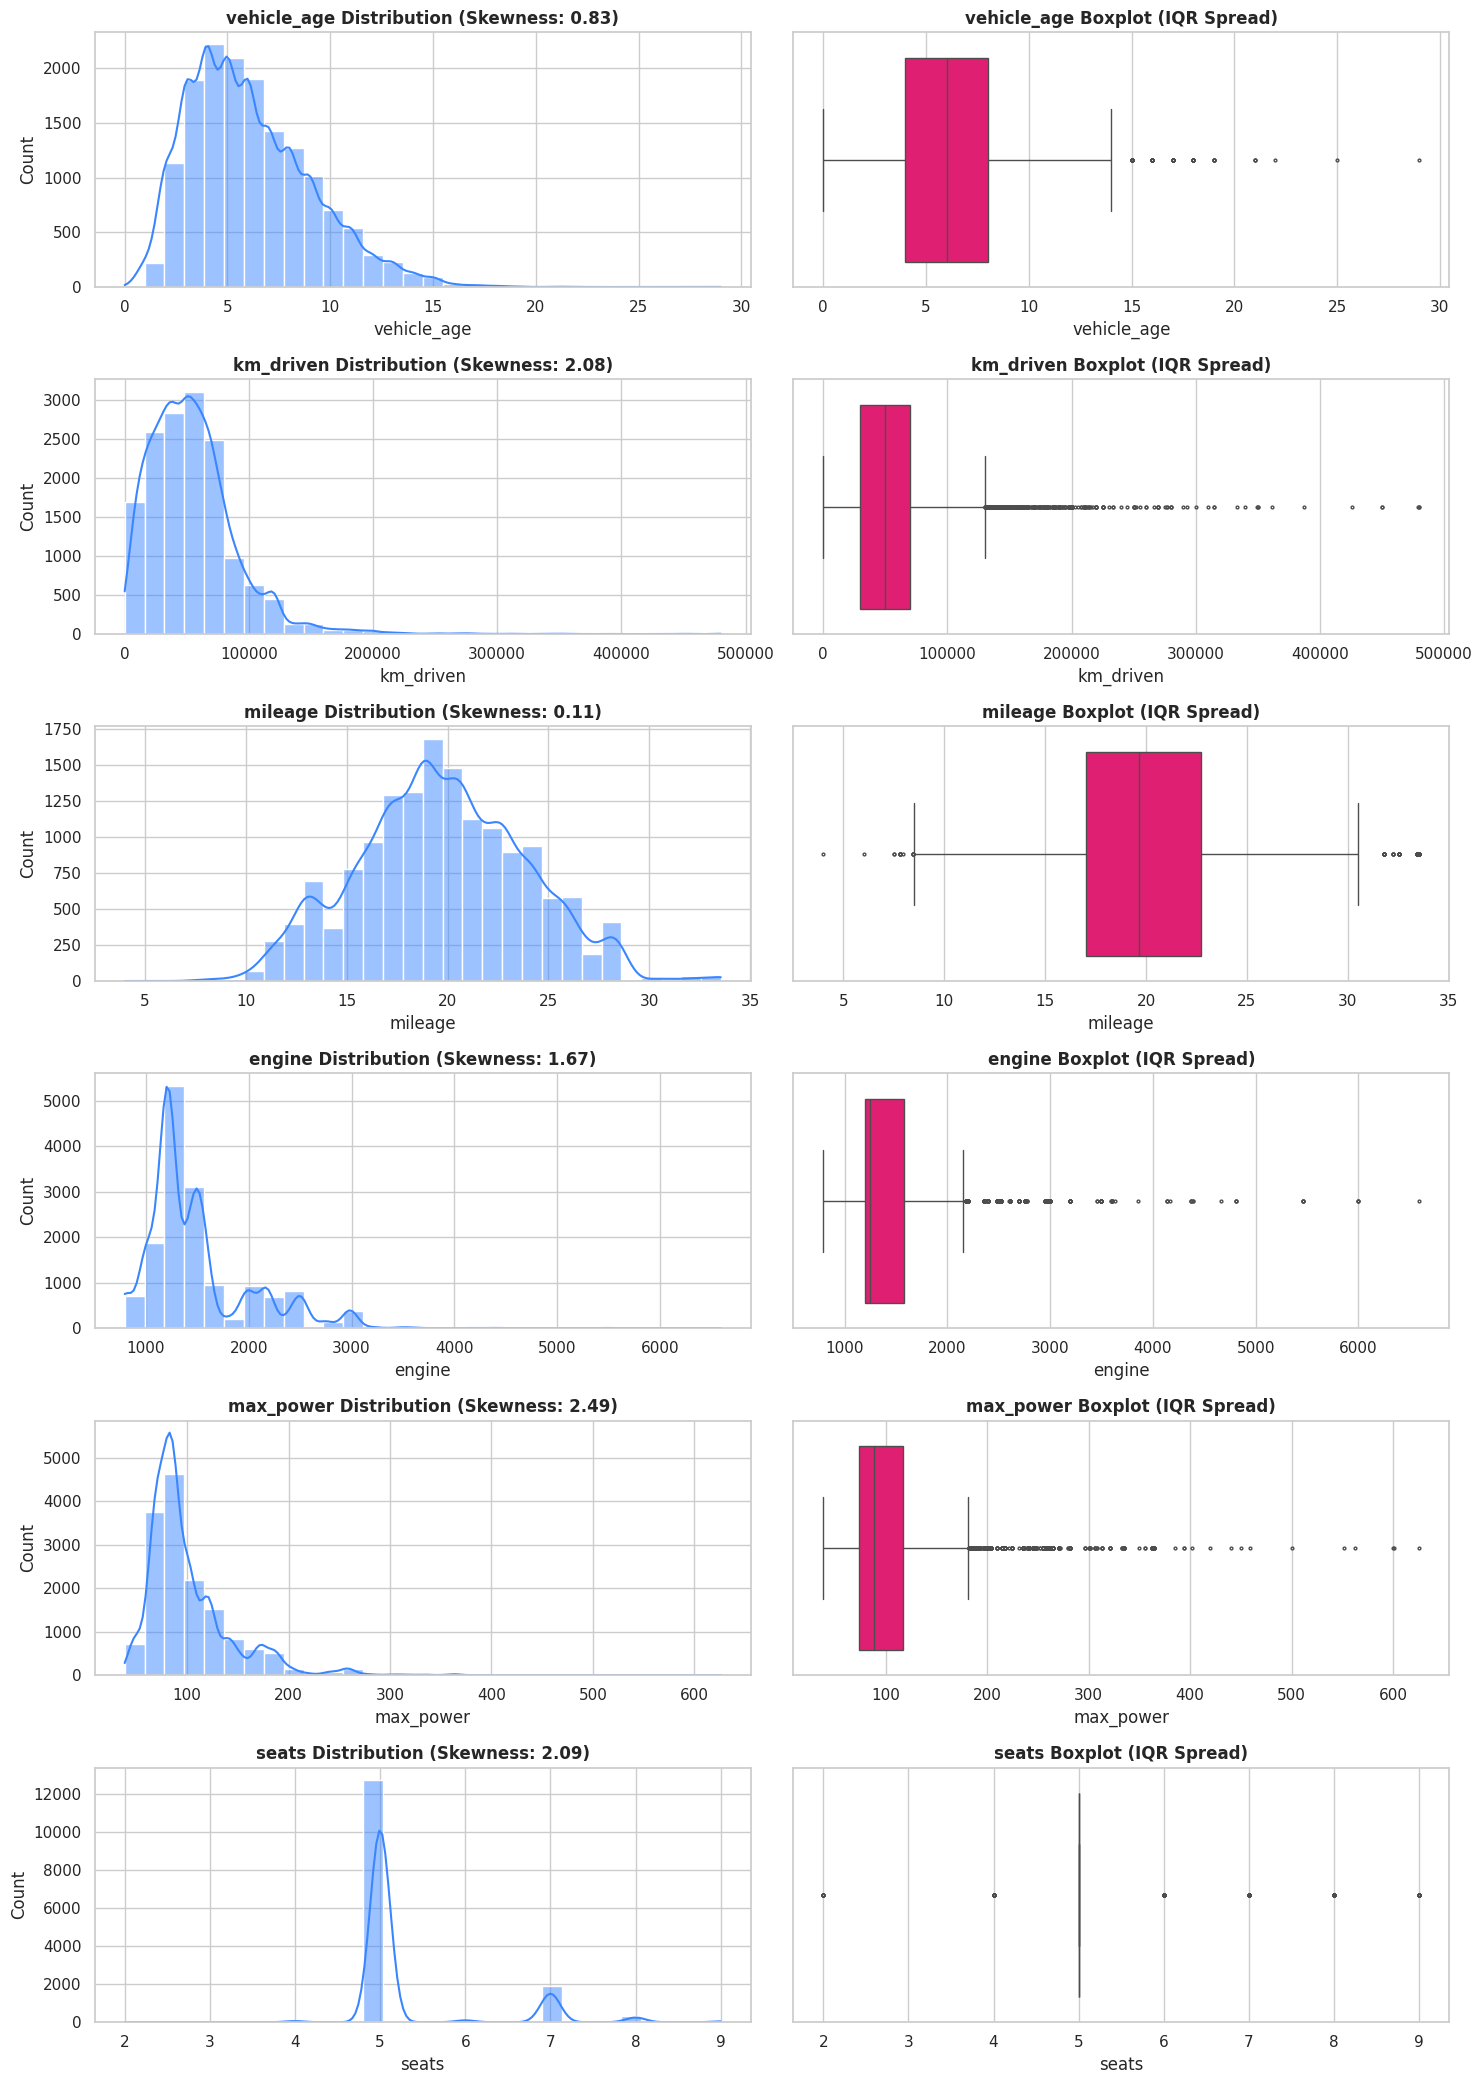

In [63]:
# Plot Histograms & Boxplots for all numerical features
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(15, 3.5 * len(numeric_cols)))

for idx, col in enumerate(numeric_cols):
    skew_val = df[col].skew()

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[idx, 0], color="#3a86ff", bins=30)
    axes[idx, 0].set_title(f"{col} Distribution (Skewness: {skew_val:.2f})", fontweight="bold")
    axes[idx, 0].set_ylabel("Count")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[idx, 1], color="#ff006e", flierprops={"marker": "o", "markersize": 2})
    axes[idx, 1].set_title(f"{col} Boxplot (IQR Spread)", fontweight="bold")

plt.tight_layout()
plt.show()

Categorical Feature Frequencies

/tmp/ipykernel_1911/1277973127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[idx], order=prop.index, palette="viridis")
/tmp/ipykernel_1911/1277973127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[idx], order=prop.index, palette="viridis")
/tmp/ipykernel_1911/1277973127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[idx], order=prop.index, palette="viridis")


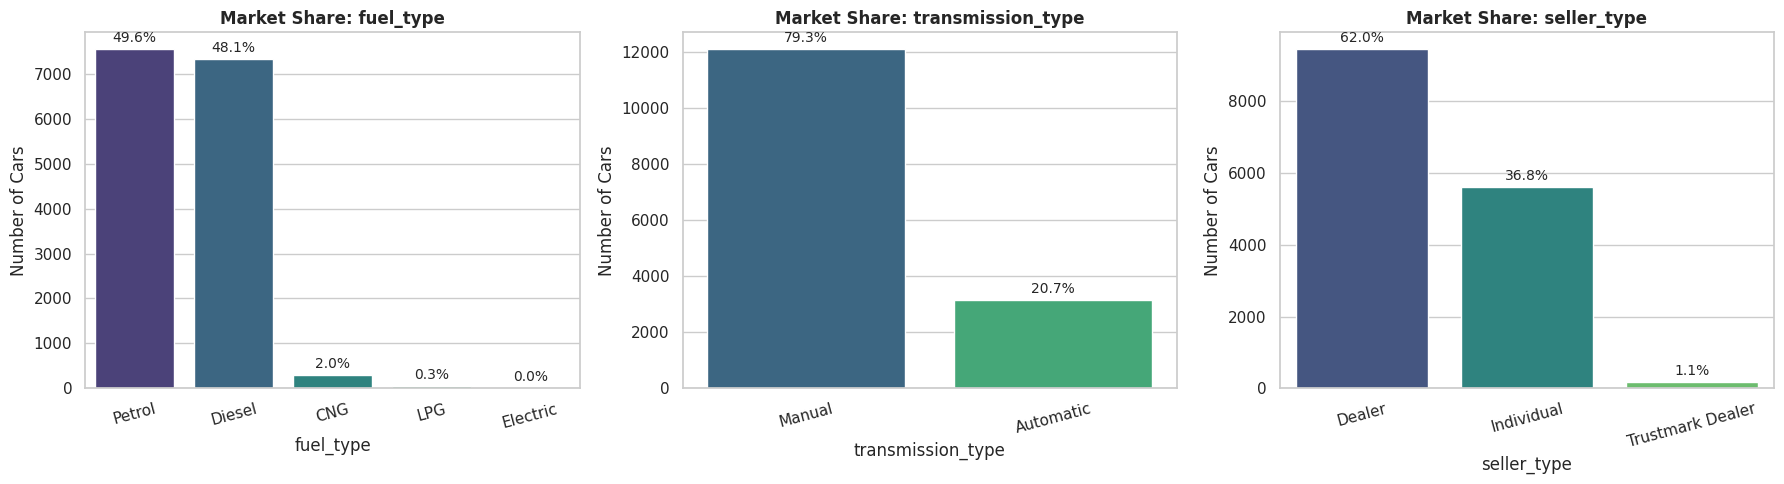

In [64]:
categorical_cols = ["fuel_type", "transmission_type", "seller_type"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(categorical_cols):
    # Proportions
    prop = df[col].value_counts(normalize=True) * 100

    sns.countplot(data=df, x=col, ax=axes[idx], order=prop.index, palette="viridis")
    axes[idx].set_title(f"Market Share: {col}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("Number of Cars")
    axes[idx].tick_params(axis="x", rotation=15)

    # Add percentage labels on top of bars
    for p in axes[idx].patches:
        height = p.get_height()
        percentage = (height / len(df)) * 100
        axes[idx].annotate(f"{percentage:.1f}%",
                           (p.get_x() + p.get_width() / 2., height),
                           ha="center", va="bottom", fontsize=10, xytext=(0, 3),
                           textcoords="offset points")

plt.tight_layout()
plt.show()

Bivariate Analysis (Predictors vs. Target)

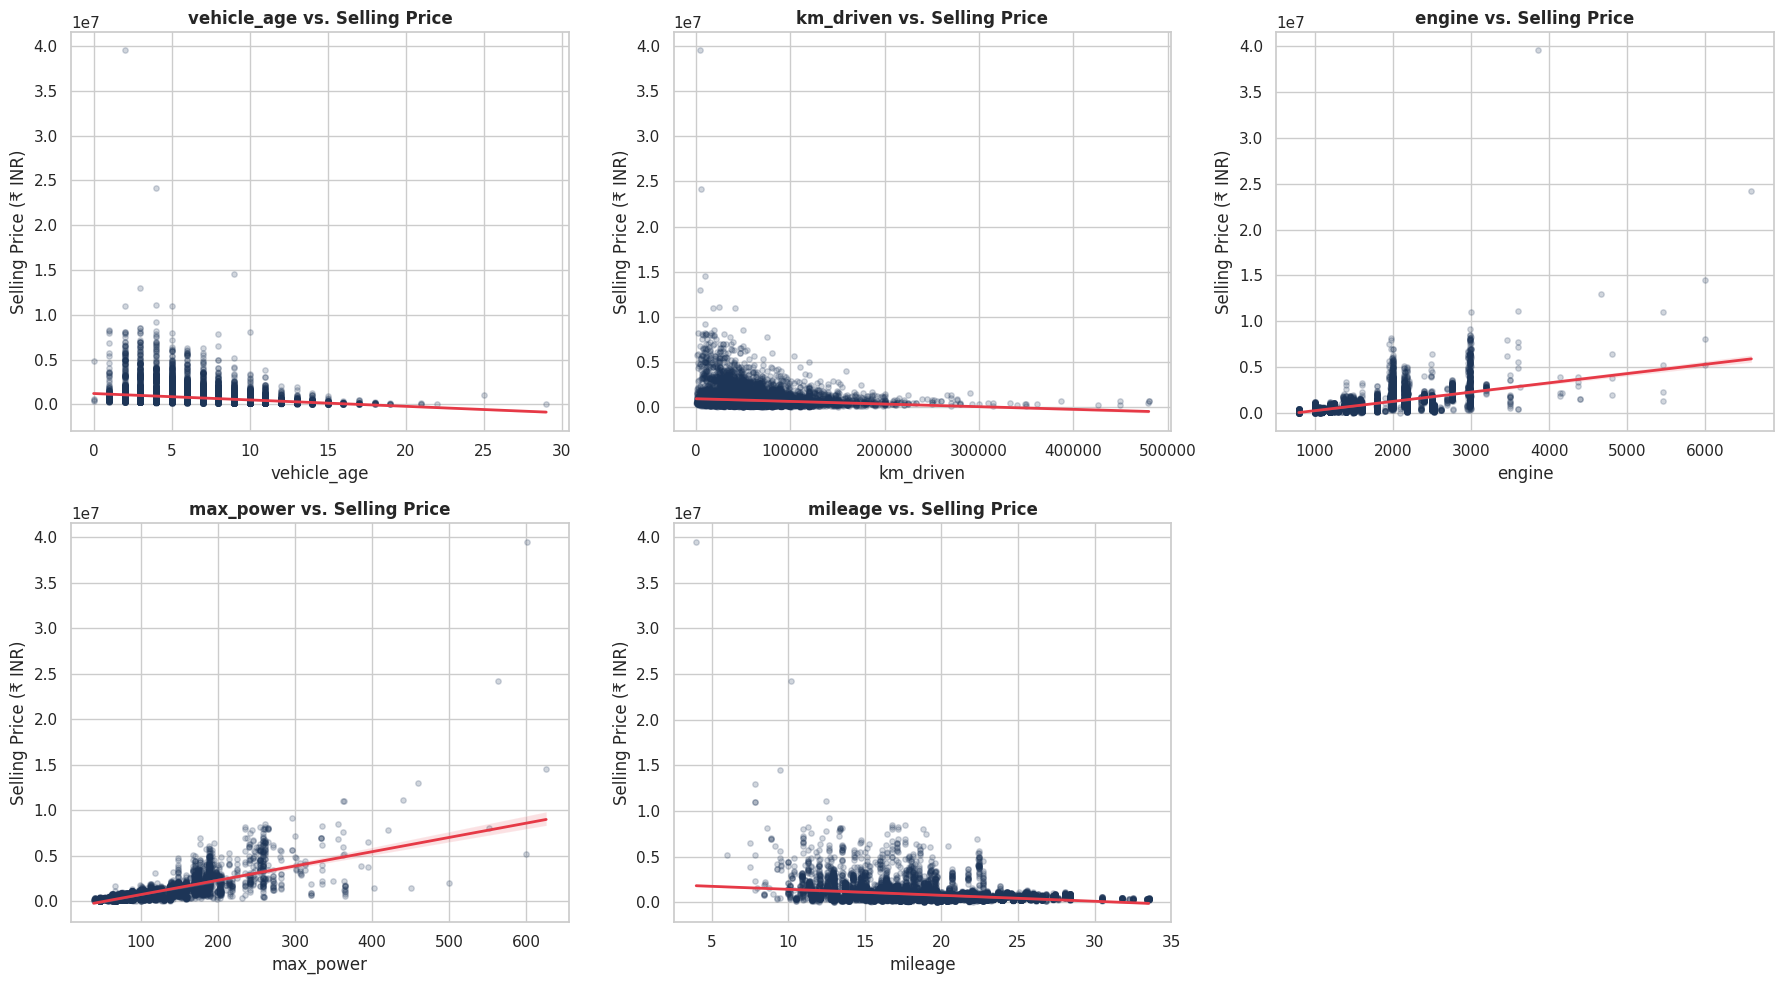

/tmp/ipykernel_1911/1460635101.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="selling_price", ax=axes[idx], palette="Set1", showmeans=True)
/tmp/ipykernel_1911/1460635101.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="selling_price", ax=axes[idx], palette="Set1", showmeans=True)
/tmp/ipykernel_1911/1460635101.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="selling_price", ax=axes[idx], palette="Set1", showmeans=True)


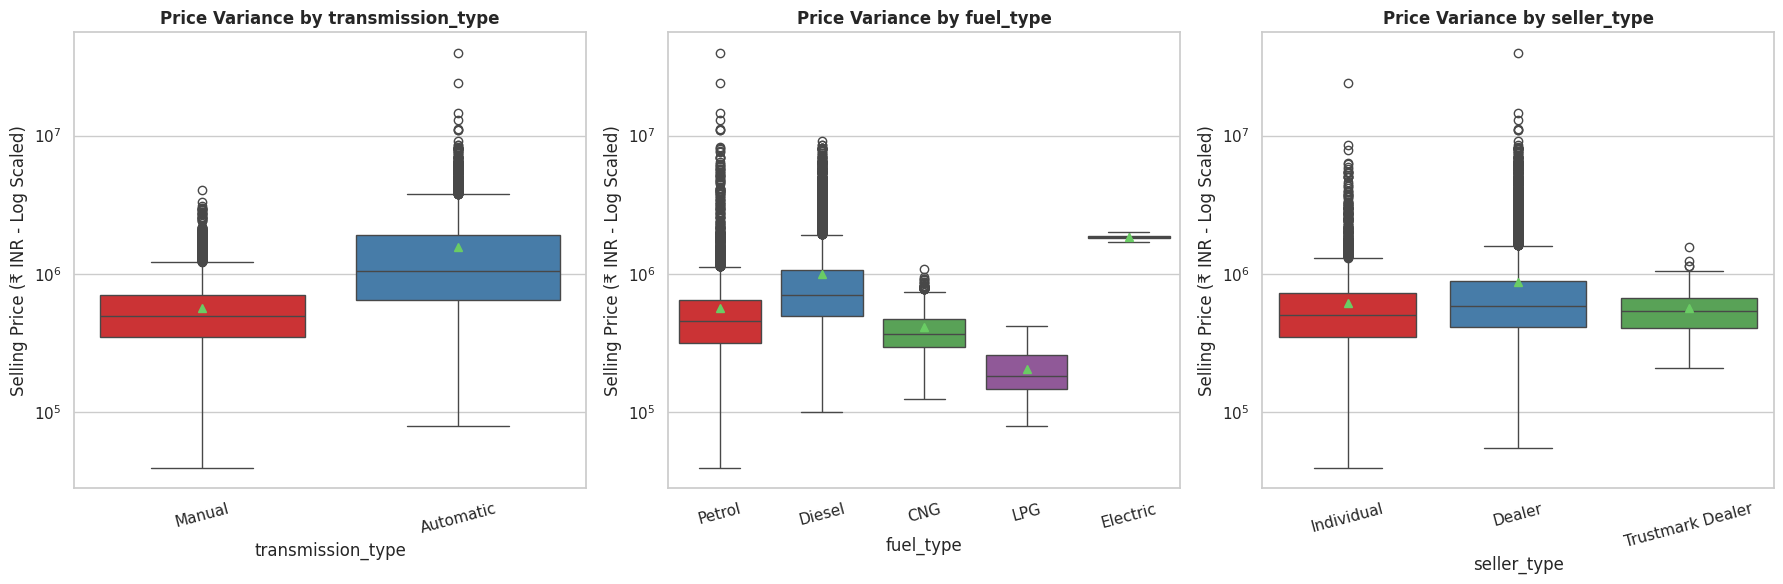

In [65]:
# 1. Continuous Features vs Selling Price (Scatter & Regplot)
continuous_features = ["vehicle_age", "km_driven", "engine", "max_power", "mileage"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(continuous_features):
    sns.regplot(
        data=df,
        x=col,
        y="selling_price",
        ax=axes[idx],
        scatter_kws={"alpha": 0.2, "color": "#1d3557", "s": 15},
        line_kws={"color": "#e63946", "linewidth": 2}
    )
    axes[idx].set_title(f"{col} vs. Selling Price", fontweight="bold")
    axes[idx].set_ylabel("Selling Price (₹ INR)")

# Hide empty subplot at position 5
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 2. Categorical Drivers vs Selling Price (Boxplots with log scale)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, col in enumerate(["transmission_type", "fuel_type", "seller_type"]):
    sns.boxplot(data=df, x=col, y="selling_price", ax=axes[idx], palette="Set1", showmeans=True)
    axes[idx].set_title(f"Price Variance by {col}", fontweight="bold")
    axes[idx].set_yscale("log")  # Using log scale to view medians clearly despite outliers
    axes[idx].set_ylabel("Selling Price (₹ INR - Log Scaled)")
    axes[idx].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Bivariate analysis showed an inverse relationship between vehicle age and price reflecting market depreciation, while engine displacement and maximum power exhibited strong positive correlations with valuation."

Multivariate Analysis (Correlation & Collinearity)

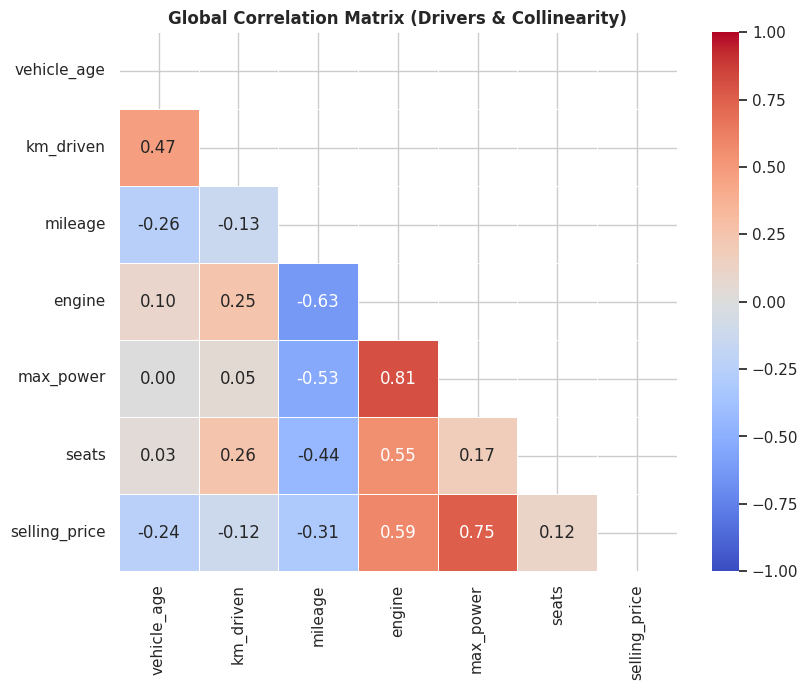

--- RANKED CORRELATION WITH SELLING PRICE ---
selling_price    1.00
max_power        0.75
engine           0.59
seats            0.12
km_driven       -0.12
vehicle_age     -0.24
mileage         -0.31

--- HIGH FEATURE-TO-FEATURE COLLINEARITY PAIRS (|r| > 0.65) ---


,Feature_1,Feature_2,Pearson_r
12,engine,max_power,0.81


In [69]:
num_cols_including_target = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price",

]
corr = df[num_cols_including_target].corr(method="pearson")

# 2. Plot Global Correlation Heatmap (Feature-vs-Target AND Feature-vs-Feature)
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Global Correlation Matrix (Drivers & Collinearity)", fontweight="bold"
)
plt.show()
# 3. Print Ranked Correlation with Selling Price
print("--- RANKED CORRELATION WITH SELLING PRICE ---")
target_corr = corr_matrix["selling_price"].sort_values(ascending=False)
print(target_corr.to_string())
# 3. Filter strong Feature-to-Feature collinearity (|r| > 0.65, excluding target)
print("\n--- HIGH FEATURE-TO-FEATURE COLLINEARITY PAIRS (|r| > 0.65) ---")
feature_corr = corr.drop(index="selling_price", columns="selling_price")
high_corr = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["Feature_1", "Feature_2", "Pearson_r"]
display(
    high_corr[high_corr["Pearson_r"].abs() >= 0.65].sort_values(
        by="Pearson_r", ascending=False
    )
)

The correlation heatmap revealed a high correlation between engine and max_power, indicating strong collinearity that must be accounted for using regularized algorithms like Ridge or tree-based ensembles